In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

In [43]:
df = sk.datasets.fetch_california_housing()

In [44]:
sk.datasets.fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [45]:
dataset = pd.DataFrame(df.data)

In [46]:
dataset.columns = df.feature_names

In [47]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [48]:
# independent features and dependent features 
X = dataset
y = df.target

In [49]:
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size = 0.30, random_state = 42 )

In [50]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [51]:
# standardizing the dataset

scaler = sk.preprocessing.StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



In [52]:
# appling linear regression
regreesion = sk.linear_model.LinearRegression()
regreesion = regreesion.fit(x_train,y_train)
mse = sk.model_selection.cross_val_score(regreesion, x_train, y_train, scoring='neg_mean_squared_error', cv = 5)

In [53]:
mse

array([-0.54787556, -0.500835  , -0.52045639, -0.51612252, -0.54883741])

In [54]:
np.mean(mse)

np.float64(-0.5268253746355749)

In [60]:
regreesion.score(x_train, y_train)

0.6093459727972159

In [61]:
regreesion.score(x_test, y_test)

0.5957702326061665

In [ ]:
reg_test_pred = regreesion.predict(x_test)



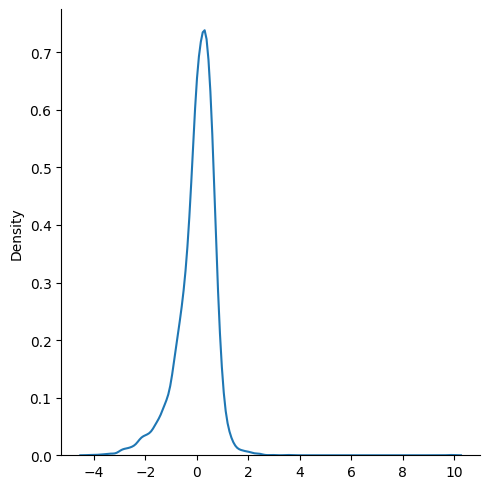

In [ ]:
sns.displot(reg_test_pred - y_test, kind='kde')